In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv("online_shoppers_intention.csv")
print(df.shape)
df.head()

(12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [5]:
# dropping any rows with missing data just to keep things clean
df.dropna(inplace=True)
print(f"Shape after cleaning: {df.shape}")

Shape after cleaning: (12330, 18)


In [6]:
# need to convert the categorical columns to numbers so the model can use them
le = LabelEncoder()
df['Month'] = le.fit_transform(df['Month'])
df['VisitorType'] = le.fit_transform(df['VisitorType'])
df['Weekend'] = df['Weekend'].astype(int)
df['Revenue'] = df['Revenue'].astype(int)

df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,2,1,1,1,1,2,0,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,2,2,2,1,2,2,0,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,2,4,1,9,3,2,0,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,2,3,2,2,4,2,0,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,2,3,3,1,4,2,1,0


In [7]:
X = df.drop('Revenue', axis=1)
y = df['Revenue']

print(f"Features: {X.shape}")
print(f"Target balance: {y.value_counts().to_dict()}")

Features: (12330, 17)
Target balance: {0: 10422, 1: 1908}


In [8]:
# 80/20 train test split, stratify so we keep the same ratio of buyers in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]}")
print(f"Test size: {X_test.shape[0]}")
print(f"\nTrain class balance BEFORE SMOTE: {y_train.value_counts().to_dict()}")

Train size: 9864
Test size: 2466

Train class balance BEFORE SMOTE: {0: 8338, 1: 1526}


In [9]:
# apply SMOTE to balance the training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Train class balance AFTER SMOTE: {pd.Series(y_train_smote).value_counts().to_dict()}")
print(f"Train size went from {X_train.shape[0]} to {X_train_smote.shape[0]}")

Train class balance AFTER SMOTE: {0: 8338, 1: 8338}
Train size went from 9864 to 16676


In [10]:
# scaling the features so everything is on the same scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

In [11]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train_smote)
print("Model trained")

Model trained


In [12]:
# getting predictions and probabilities
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# printing out all the metrics
print(classification_report(y_test, y_pred, target_names=['No Purchase', 'Purchase']))
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_prob):.4f}")

              precision    recall  f1-score   support

 No Purchase       0.94      0.89      0.92      2084
    Purchase       0.54      0.69      0.61       382

    accuracy                           0.86      2466
   macro avg       0.74      0.79      0.76      2466
weighted avg       0.88      0.86      0.87      2466

Accuracy:  0.8621
Precision: 0.5430
Recall:    0.6937
F1 Score:  0.6092
ROC AUC:   0.8594


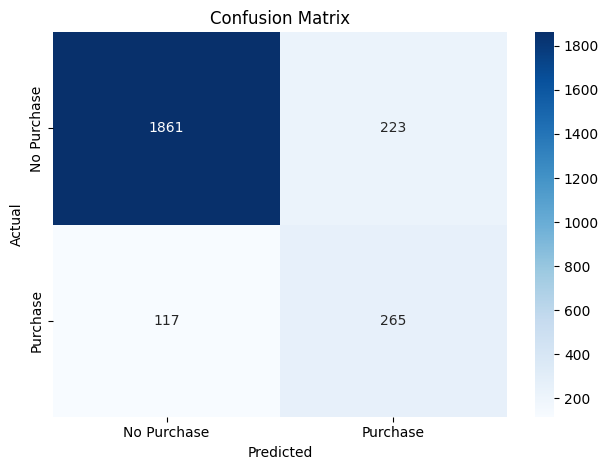

In [13]:
# confusion matrix to see where the model is getting things right and wrong
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Purchase', 'Purchase'],
            yticklabels=['No Purchase', 'Purchase'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

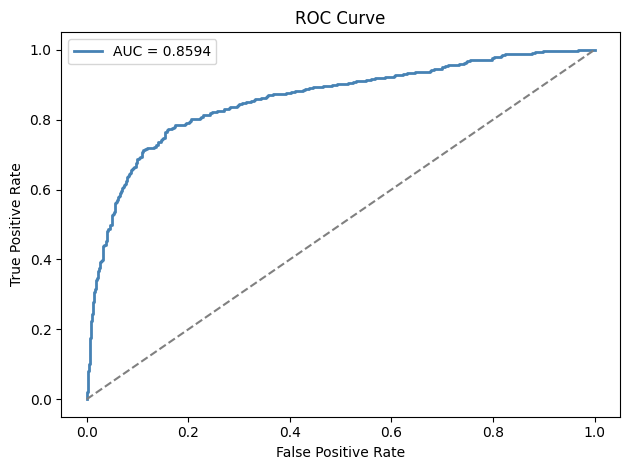

In [14]:
# roc curve shows how well the model separates the two classes
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc:.4f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()

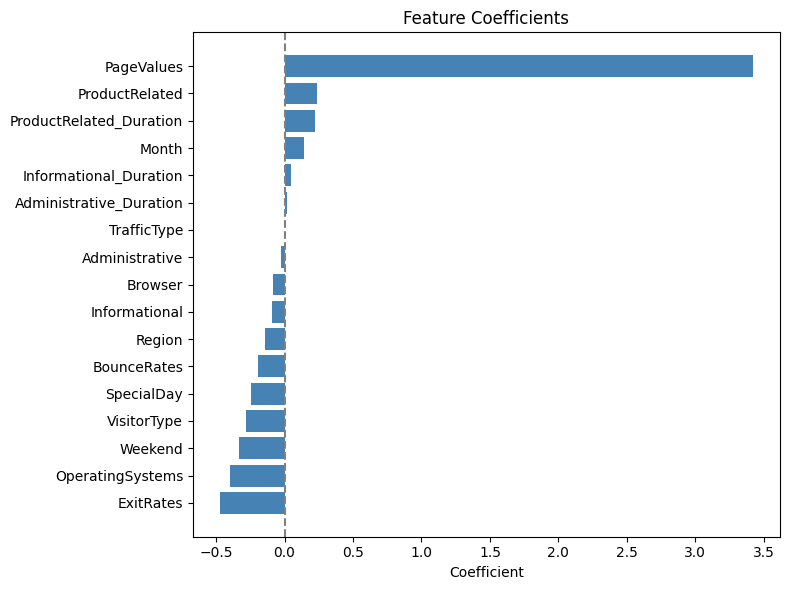

In [15]:
# looking at which features matter most based on the model coefficients
coefs = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_[0]})
coefs = coefs.sort_values('Coefficient')

plt.figure(figsize=(8, 6))
plt.barh(coefs['Feature'], coefs['Coefficient'], color='steelblue')
plt.xlabel('Coefficient')
plt.title('Feature Coefficients')
plt.axvline(x=0, color='gray', linestyle='--')
plt.tight_layout()
plt.show()